## __Building a Profile Hidden Markov Model for the detection of Kunitz Type Protease Inhibitor Domain__

Core libraries used throughout the notebook

In [1]:
import pandas as pd
from Bio import SeqIO
import matplotlib.pyplot as plt
import seaborn as sns

### __1. Extract Kunitz domain sequences from UniProt:__
Using the advance search function in UniProt to download the sequences of all the proteins showing a Kunitz domain, applying the following filters:

° Pfam ID: PF 00014

° Resolution ≤ 3.5 Angstrom

° Sequence length: 40 ≤ length ≤ 80 residues 

The file downlowded: `rcsb_pdb_custom_report_20260818144409.csv`

In [2]:
df = pd.read_csv('rcsb_pdb_custom_report_20260818144409.csv', header= 1)
df.head()

,Entry ID,Sequence,Auth Asym ID,Entity ID,Unnamed: 4
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,B,1.0,NaN
1,NaN,NaN,A,NaN,NaN
2,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,B,1.0,NaN
3,NaN,NaN,A,NaN,NaN
4,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,1.0,NaN


In [3]:
df.shape

(412, 5)

### __2. Filtering and cleaning data__

Clean the dataset in preparation for the clustering and the structure-based multiple alignment

° Drop unnecessary column

In [4]:
df.dropna(how='all', axis=1, inplace=True)
df.head()

,Entry ID,Sequence,Auth Asym ID,Entity ID
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,B,1.0
1,NaN,NaN,A,NaN
2,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,B,1.0
3,NaN,NaN,A,NaN
4,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,1.0


° Drop rows that contain missing (null) values

In [5]:
df= df.dropna()
df.head()

,Entry ID,Sequence,Auth Asym ID,Entity ID
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,B,1.0
2,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,B,1.0
4,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,1.0
9,1BHC,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,B,1.0
19,1BPI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,1.0


In [6]:
df.shape

(135, 4)

° Keep only sequences between 40 and 80 amino acids long.
  Kunitz domains cannot be shorter or longer than this range

In [7]:
df_clean = df[(df['Sequence'].str.len() > 40) & (df['Sequence'].str.len() < 80)]
df_clean.head()

,Entry ID,Sequence,Auth Asym ID,Entity ID
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,B,1.0
2,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,B,1.0
4,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,D,1.0
9,1BHC,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,B,1.0
19,1BPI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,1.0


In [8]:
df_clean.shape

(125, 4)

Final size of the cleaned dataset used for the alignment step.

### __3. Structure-based multiple alignment__

The cleaned DataFrame (125 sequences) is exported to FASTA format and submitted to MMseqs2, an online bioinformatics tool used here to cluster the sequences and remove redundancy from the dataset.

° Convert the cleaned DataFrame into a FASTA file called `mmseqs2.fasta` for MMseqs2 clustering

In [9]:
with open('mmseqs2.fasta', 'w') as fasta:
        for index, row in df_clean.iterrows():
            fasta.write(f">{row['Entry ID']}:{row['Auth Asym ID']}\n")       # header: PDB_ID: chain
            fasta.write(f"{row['Sequence']}\n")                              # sequence line

° Extract cluster representative headers from the MMseqs2 output file `mmseqs2_6804234.out`

In [10]:
with open ('mmseqs2_6804234.out', 'r') as clusters, open ('PDBefold.txt', 'w') as output:
    for line in clusters:
        line= line.strip()
        if '>' in line:
            output.write(f'{line[1:]}\n')

The file `PDBefold.txt` contain ID's and chains needed in the PDBeFold tool for the MSA.  
PDBeFold create the file `PdBefold_fasta_result.seq`

° Uppercase the sequence line of `PdBefold_fasta_result.seq` and create the file `kunitz_aligned.fasta` with the cluster representative headers and the aligned sequences

In [11]:
with open("PdBefold_fasta_result.seq", "r") as file_in, open("kunitz_aligned.fasta", "w") as file_out:
    for line in file_in:
        if line.startswith(">"):
            file_out.write(line) 
        else:
            file_out.write(line.upper()) 

° Creating a plot tho show the outliers for the RMSD value

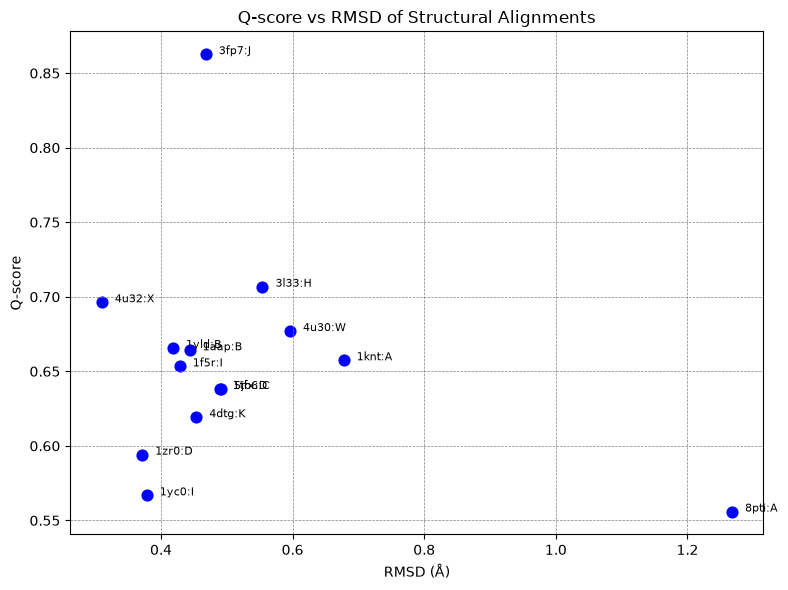

In [12]:
structures = ["1aap:B","1f5r:I","1knt:A","1tfx:D","1yc0:I","1yld:B","1zr0:D",
              "3fp7:J","3l33:H","4dtg:K","4u30:W","4u32:X","5jb6:C","8pti:A"]

rmsd = [0.4434,0.4283,0.6774,0.4890,0.3782,0.4181,0.3713,
                  0.4679,0.5540,0.4534,0.5958,0.3099,0.4911,1.2675]

qscore = [0.6641,0.6533,0.6574,0.6382,0.5668,0.6656,0.5941,
          0.8627,0.7067,0.6192,0.6770,0.6963,0.6381,0.5559]

dfRMSD = pd.DataFrame({
    "structure": structures,
    "RMSD": rmsd,
    "Q_score": qscore,
})
plt.figure(figsize=(8, 6))
plt.scatter(dfRMSD["RMSD"], dfRMSD["Q_score"], color='blue', s=60)
plt.xlabel("RMSD (Å)")
plt.ylabel("Q-score")
plt.title("Q-score vs RMSD of Structural Alignments")


plt.grid(True, which = "both", linestyle = "--",linewidth = 0.5, color="gray")

for i, row in dfRMSD.iterrows():
    plt.text(row["RMSD"] + 0.02, row["Q_score"], row["structure"], fontsize=8)

plt.tight_layout()
plt.show()

Manually remove the high-RMSD sequences from `kunitz_aligned.fasta` to produce `kunitz_aligned_clean.fasta`. In the plot we can see how the only high-RMSD sequence is __PDB:8pti__

### __4. HMM Building__

Build the HMM profile from the cleaned and aligned sequences using HMMER on the command line:

- input file: the cleaned, aligned Kunitz sequences `kunitz_aligned_clean.fasta` 
- output file: the trained HMM profile `kunitz_model.hmm`

```bash
hmmbuild kunitz_model.hmm kunitz_aligned_clean.fasta

Build the positive/negative datasets to evaluate the HMM on the command line:

° Decompress the UniProt downloaded file  with the reviewed proteins that do NOT have the Kunitz Pfam domain annotation, this becomes the negative dataset `negative_kunitz.fasta`
```bash
zcat -f uniprotkb_reviewed_true_NOT_xref_pfam_P.fasta.gz > negative_kunitz.fasta


° Decompress the UniProt downloaded file of reviewed proteins that DO have the Kunitz Pfam domain annotation (PF00014), this becomes the positive Kunitz dataset positive_kunitz.fasta
```bash
zcat -f uniprotkb_reviewed_true_AND_xref_pfam_P_2026_08_25.fasta.gz  > positive_kunitz.fasta

Training Sequences must be excluded from the positive dataset because evaluating a statistical model on the exact same data used to construct it introduces severe data leakage.

To exclude the right sequence we need to map between UniProt and PDB different IDs, so we used SIFTS a bioinformatic tool from the PDBe-KB resource

° Extract the IDs from the `kunitz_aligned_clean.fasta`


In [13]:
my_ids= []

with open('kunitz_aligned_clean.fasta', 'r') as file:
    for line in file:
        line= line.strip()
        if line.startswith('>'):
            ids = line.split(' ')
            my_ids.append(ids[0][5:].upper())
print(my_ids)

['1AAP:B', '1F5R:I', '1KNT:A', '1TFX:D', '1YC0:I', '1YLD:B', '1ZR0:D', '3FP7:J', '3L33:H', '4DTG:K', '4U30:W', '4U32:X', '5JB6:C']


° Split each ID into PDB code and chain. PDB code lowercase / chain uppercase to match the SIFTS mapping file used below

In [14]:
my_pairs = set()
for entry in my_ids:
    pdb, chain = entry.split(":")
    my_pairs.add((pdb.lower(), chain.upper()))

° Download the mapping SIFTS PDB → UniProt, and decompress it in a csv file `pdb_chain_uniprot.csv`
```bash
wget https://ftp.ebi.ac.uk/pub/databases/msd/sifts/flatfiles/csv/pdb_chain_uniprot.csv.gz
gunzip pdb_chain_uniprot.csv.gz

° Map PDB:chain pairs to UniProt accessions using the SIFTS cross-reference table

In [15]:
sifts = pd.read_csv("pdb_chain_uniprot.csv", skiprows=1)
sifts["PDB"] = sifts["PDB"].str.lower()
sifts["CHAIN"] = sifts["CHAIN"].str.upper()
sifts["pair"] = list(zip(sifts["PDB"], sifts["CHAIN"]))
matched = sifts[sifts["pair"].isin(my_pairs)]
my_uniprot_ids = set(matched["SP_PRIMARY"])

print(f"Found {len(my_uniprot_ids)} UniProt IDs matching {len(my_pairs)} PDB:chain pairs")
print(my_uniprot_ids)

/tmp/ipykernel_1350/1472893721.py:1: DtypeWarning: Columns (0: PDB_END) have mixed types. Specify dtype option on import or set low_memory=False.
  sifts = pd.read_csv("pdb_chain_uniprot.csv", skiprows=1)


Found 8 UniProt IDs matching 13 PDB:chain pairs
{'O43291', 'O43278', 'P00974', 'P05067', 'P48307', 'P12111', 'P10646', 'P02760'}


° Check if some chain pairs did NOT find a match in SIFTS

In [16]:
found_pairs = set(matched["pair"])
missing = my_pairs - found_pairs
print(missing)

set()


° Remove from the positive set `positive_kunitz.fasta` any sequence whose UniProt ID was already used to build
the training alignment, creating the new file `positive_clean_kunitz.fasta`

In [17]:

records = list(SeqIO.parse("positive_kunitz.fasta", "fasta"))

def get_accession(record):
    parts = record.id.split("|")
    return parts[1] if len(parts) > 1 else record.id

filtered = [r for r in records if get_accession(r) not in my_uniprot_ids]
removed = [r for r in records if get_accession(r) in my_uniprot_ids]

SeqIO.write(filtered, "positive_clean_kunitz.fasta", "fasta")

print("Removed IDs:", [get_accession(r) for r in removed])

Removed IDs: ['O43278', 'O43291', 'P00974', 'P02760', 'P05067', 'P10646', 'P12111', 'P48307']


Search both sequence sets against the HMM profile with HMMER:  
- input file: the HMM profile built above `kunitz_model.hmm` and `positive_clean_kunitz.fasta`/ `negative_kunitz.fasta` 
- output file: Tabular Hit Table with columns containing: target names, accession numbers, E-values, bit scores, and domain coordinates `positive_kunitz.search` `negative_kunitz.search`

° Scan the positive set against the Kunitz HMM profile
```bash
hmmsearch --max --noali --tblout positive_kunitz.search -Z 1000 kunitz_model.hmm positive_clean_kunitz.fasta

° Scan the negative set against the Kunitz HMM profile
```bash
hmmsearch --max --noali --tblout negative_kunitz.search -Z 1000 kunitz_model.hmm negative_kunitz.fasta

### __5 Data preparation__

Build the labeled positive/negative match files, then split them into two folds for testing

° Turn the raw hmmsearch output into simple 3-column match files with ID, E-value and label (0 = negative not a real Kunitz domain, 1 = positive real Kunitz domain) creating 2 files: `negative_kunitz.match` `positive_kunitz.match`
```bash

grep -v '^#' negative_kunitz.search |awk '{print $1"\t"$8"\t0"}' > negative_kunitz.match
grep -v '^#' positive_kunitz.search |awk '{print $1"\t"$8"\t1"}' > positive_kunitz.match

Hmmsearch only reports lines for sequences that scored a hit; sequences with zero hits are simply absent from `negative_kunitz.search`, so they need to be added back in manually as "no match" cases

° Recover negative sequences that hmmsearch found NO hit for at all
```bash

grep ">" negative_kunitz.fasta | awk '{print $1}' | tr -d ">" | sort >negative_kunitz.ids
awk '{print $1}' negative_kunitz.match |sort >negative_kunitz_match.ids
comm negative_kunitz.ids negative_kunitz_match.ids |less
comm -23 negative_kunitz.ids negative_kunitz_match.ids |less
comm -23 negative_kunitz.ids negative_kunitz_match.ids |less |awk '{print $1"\t100\t0"}' > negative_kunitz.nomatch

° Combine and shuffle the full negative set creating `negative_kunitz_tot.match`
```bash

cat negative_kunitz.match negative_kunitz.nomatch | sort -R > negative_kunitz_tot.match

° Shuffle the positive set `positive_kunitz.match` too creating `positive_kunitz_random.match`
```bash

cat positive_kunitz.match | sort -R > positive_kunitz_random.match

° Build two test folds `kunitz_set_1.txt` and `kunitz_set_2.txt`, each combining some positives with negatives
```bash
head -n 194 positive_kunitz_random.match > kunitz_set_1.txt
tail -n 195 positive_kunitz_random.match > kunitz_set_2.txt
head -n 287553 negative_kunitz_tot.match >> kunitz_set_1.txt
tail -n 287552 negative_kunitz_tot.match >> kunitz_set_2.txt

### __6. Performance evaluation__

Evaluate performance using a python script called `performance.py` that gives us:
- Q2 that represents the Accuracy
- MCC (Matthews Correlation Coefficient)
- Confusion matrix (TN, TP, FN, FP)

In [18]:
import numpy as np

def get_preds(fname):
    preds = []
    with open(fname, 'r') as f:
        for line in f:
            v=line.rstrip().split()
            #preds.append([v[0],float(v[2]),int(v[3])])
            preds.append([v[0],float(v[1]),int(v[2])])
    return preds


def get_cm(preds, th=0.001):
    cm = np.zeros((2, 2))
    n = len(preds)
    for k in range(n):
        j = 0
        i = preds[k][2]
        if preds[k][1] <= th:
            j=1
        cm[i][j] += 1
    return cm


def get_accuracy(cm):
    return (cm[0][0]+cm[1][1])/(cm.sum())


def get_mcc(cm):
    tp =cm[1,1]
    tn =cm[0,0]
    fp =cm[0,1]
    fn =cm[1,0]
    d = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    mcc = (tp*tn-fp*fn)/np.sqrt(d) 
    return mcc

° Loop over exponents 1 to 15, building thresholds 1e-1 to 1e-15. This command create a file per set `kunitz_set_1.results` and `kunitz_set_2.results` with Q2, MCC and the values of the confusion matrix for every different threshold
```bash
for i in {1..15}; do python3 performance.py kunitz_set_1.txt 1e-$i; done > kunitz_set_1.results
for i in {1..15}; do python3 performance.py kunitz_set_2.txt 1e-$i; done > kunitz_set_2.results

° The plot that shows the connection beetween e-values and MCC using the values from `kunitz_set_1.results` and `kunitz_set_2.results` files

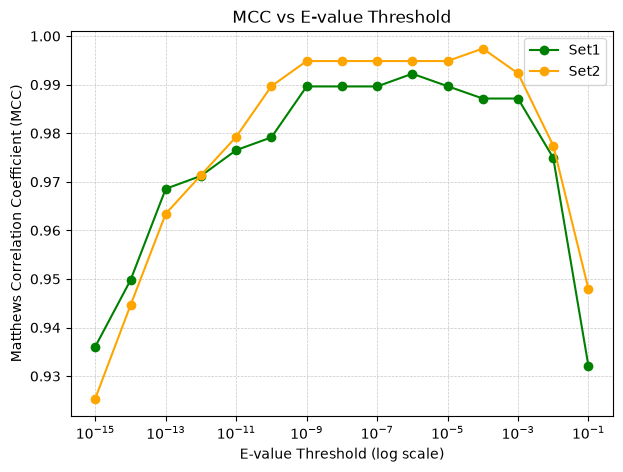

In [19]:
data_set1 = {
    'Threshold': [0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07, 1e-08, 1e-09, 1e-10, 1e-11, 1e-12, 1e-13, 1e-14, 1e-15],
    'MCC': [0.9320478037975016, 0.9749293326967127, 0.9871411017204932, 0.9871411017204932, 
            0.9896837664099287, 0.9922461626835732, 0.9896301429440034, 0.9896301429440034, 
            0.9896301429440034, 0.9791507614447283, 0.9765133904738287, 0.9712172185797718, 
            0.9685583004751521, 0.9497379933820062, 0.9360638484243421]
}

df1 = pd.DataFrame(data_set1)

data_set2 = {
    'Threshold': [0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07, 1e-08, 1e-09, 1e-10, 1e-11, 1e-12, 1e-13, 1e-14, 1e-15],
    'MCC': [0.9479181189221818, 0.9774664969666258, 0.9923253991436117, 
            0.9974308673216228, 0.9948551180266219, 0.9948551180266219, 
            0.9948551180266219, 0.9948551180266219, 0.9948551180266219, 
            0.9896835628085254, 0.9792587400877437, 0.971366897178959, 
            0.9634105765585734, 0.9445859048256658, 0.925379312877023], 
}
df2 = pd.DataFrame(data_set2)

plt.figure(figsize=(7, 5))

# Traccia la linea del Set 1
# 'go-' significa: g=green (verde), o=circle marker, -=linea solida
plt.plot(df1['Threshold'], df1['MCC'], 'go-', label='Set1') 

# Traccia la linea del Set 2
# 'o-' con color='orange' significa: arancione, marker a cerchio, linea solida
plt.plot(df2['Threshold'], df2['MCC'], marker='o', linestyle='-', color='orange', label='Set2')

# 4. Formattazione degli assi e del grafico per renderlo identico all'immagine
plt.xscale('log') # Imposta l'asse X su scala logaritmica (fondamentale per gli E-value)
 # Inverte l'asse X, così i valori più piccoli (es. 10^-9) sono a sinistra

plt.title('MCC vs E-value Threshold')
plt.xlabel('E-value Threshold (log scale)')
plt.ylabel('Matthews Correlation Coefficient (MCC)')

# Aggiunge la griglia (linee tratteggiate leggere come nell'immagine)
plt.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.7)

# Aggiunge la legenda
plt.legend()

# 5. Mostra il grafico finale
plt.show()

Confusion matrices for the final test illustrating the distribution of true 
positives (TP), true negatives (TN), false positives (FP), and false negatives (FN) at threshold 1e-06 (highest MCC)

° Set 1

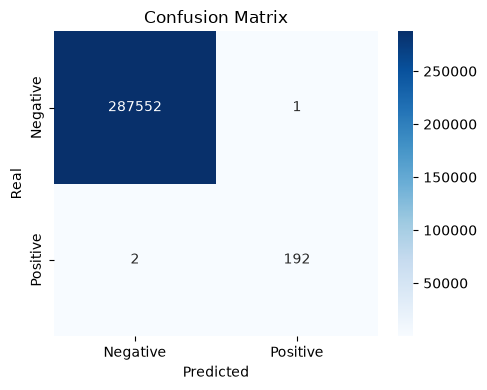

In [20]:
TN = 287552
FP = 1
FN = 2
TP = 192

cm = np.array([[TN,FP],
[FN,TP]])

labels = ["Negative", "Positive"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

° Set 2

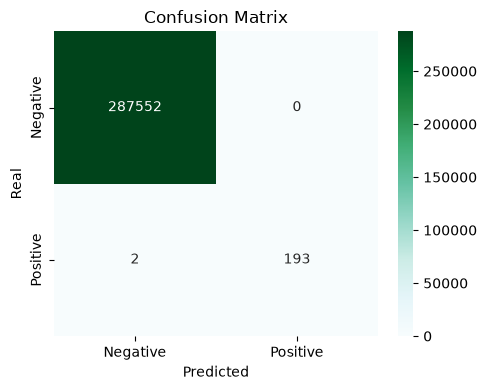

In [21]:
TN = 287552
FP = 0
FN = 2
TP = 193

cm = np.array([[TN,FP],
[FN,TP]])

labels = ["Negative", "Positive"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()